In [188]:
import pm4py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

In [189]:
# Load dataset
filepath = "generated/preprocessed_dataset.csv"
df = pd.read_csv(filepath, parse_dates=["time:timestamp"])

df["case:concept:name"] = df["case:concept:name"].astype(str)
df["time:timestamp"]= pd.to_datetime(df["time:timestamp"])

df.head()

,responsible_physician,disease,start_date,time:timestamp,concept:name,item,prescription_date,process_time,quantity,readmission_status,outlier_label,@@index,@@case_index,case:concept:name
0,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaN,0.0,0.0,Sem retorno,outlier,0,0,5446538
1,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaN,0.0,0.0,Sem retorno,outlier,1,0,5446538
2,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (...,2020-07-21 10:51:00+00:00,9.0,1.0,Sem retorno,outlier,2,0,5446538
3,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaN,0.0,0.0,Sem retorno,outlier,3,0,5446538
4,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaN,0.0,0.0,Sem retorno,outlier,4,0,5446538


In [190]:
# Incremental lead time between consecutive events in each case
df["event_lead_time_min"] = (
    df.groupby("case:concept:name")["time:timestamp"]
    .diff()
    .dt.total_seconds()
    .fillna(0)
)

# Convert event lead time to minutes
df["event_lead_time_min"] = df["event_lead_time_min"] / 60

# Cumulative lead time from the start of the case to each event
df["cumulative_lead_time_min"] = (
    df.groupby("case:concept:name")["event_lead_time_min"].cumsum()
)

In [191]:
def compute_case_kpis(segment_df: pd.DataFrame):
    """
    Compute per-case KPIs: total case duration, case size and rework count.
    Rework is computed by counting repeated activities per case (counts > 1).
    Missing rework values are filled with 0.

    Parameters
    ----------
    segment_df : pd.DataFrame
        Event log dataframe 
    
    Returns
    -------
    pd.DataFrame
        DataFrame indexed by `case:concept:name` with columns:
        - duration_min: max cumulative_lead_time_min per case
        - case_size: number of events per case
        - rework_count: sum of repeated activity counts per case (0 if none)
    """
    
    # Case Duration (total case duration = max cumulative_lead_time_min per case)
    duration = (
        segment_df.groupby("case:concept:name")["cumulative_lead_time_min"]
        .max()
        .rename("duration_min")
    )

    # Case Size (number of events per case)
    size = (
        segment_df.groupby("case:concept:name")["concept:name"]
        .count()
        .rename("case_size")
    )
    
    kpis = pd.concat([duration, size], axis=1).fillna(0)
    return kpis

In [192]:
def compute_case_kpis_tests(segment_a: pd.DataFrame, segment_b: pd.DataFrame, kpis_to_test):
    """
    Compute statistical tests to compare KPIs between two segments.
     - For each KPI, test normality with Shapiro-Wilk.
     - If both are normal, use T-test (Welch's if variances differ).
     - If at least one is non-normal, use Mann-Whitney U test.
     - Print results and conclusions for each KPI.

    Parameters
    ----------
    segment_a : pd.DataFrame
        First segment dataframe
    segment_b : pd.DataFrame
        Second segment dataframe
    kpis_to_test : list[str]
        List of KPI column names to compare
    """
    for kpi in kpis_to_test:
        data_a = segment_a[kpi].dropna()
        data_b = segment_b[kpi].dropna()

        print(f"--- KPI: {kpi} (Sample sizes: a={len(data_a)}, b={len(data_b)}) ---")
        
        # Normality test (Shapiro-Wilk)
        _, p_shapiro_a = stats.shapiro(data_a)
        _, p_shapiro_b = stats.shapiro(data_b)
        
        is_normal_a = p_shapiro_a > 0.05
        is_normal_b = p_shapiro_b > 0.05
        
        print(f"Normality of segment a (Shapiro p-value): {p_shapiro_a:.4f} -> {'Normal' if is_normal_a else 'Non-normal'}")
        print(f"Normality of segment b (Shapiro p-value): {p_shapiro_b:.4f} -> {'Normal' if is_normal_b else 'Non-normal'}")
        
        # Select test based on normality
        if is_normal_a and is_normal_b:
            print("Each sample are normal, we use T-test.")
            # equal_var=False applies Welch's t-test, which is more robust when variances are unequal
            res_test = stats.ttest_ind(data_a, data_b, equal_var=False) 
            test_name = "T-test"
        else:
            print("At least one sample is not normal. Performing Mann-Whitney U test.")
            res_test = stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
            test_name = "Mann-Whitney U"

        p_val = float(res_test.pvalue)

        # Final conclusion
        print(f"Risultato {test_name} p-value: {p_val:.4f}")
        if p_val < 0.05:
            print(f"✅ There is a statistically significant difference between the two segments for '{kpi}'.\n")
        else:
            print(f"❌ There is NOT a statistically significant difference between the two segments for '{kpi}'.\n")

### Readmission status segmentation analysis

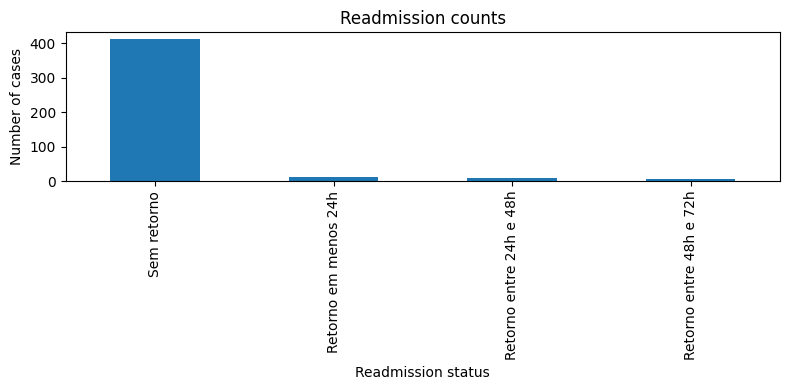

In [193]:
# Readmission frequency
readmission_counts = df.groupby("case:concept:name")["readmission_status"].first().value_counts()

ax = readmission_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Readmission counts")
ax.set_xlabel("Readmission status")
ax.set_ylabel("Number of cases")

plt.tight_layout()
plt.show()

In [194]:
# Segment by readmission status
discharged = df[df["readmission_status"] == "Sem retorno"] # cases discharged 
readmitted = df[df["readmission_status"] != "Sem retorno"] # cases readmitted

In [195]:
# Compute KPIs for each segment
kpi_discharged = compute_case_kpis(discharged)
print(f"Discharged")
display(kpi_discharged.describe())

kpi_readmitted = compute_case_kpis(readmitted)
print(f"\nReadmitted")
display(kpi_readmitted.describe())

Discharged


,duration_min,case_size
count,411.000000,411.000000
mean,129.394161,6.564477
std,199.302847,5.766819
min,8.000000,3.000000
25%,45.000000,4.000000
50%,80.000000,4.000000
75%,150.500000,5.000000
max,3221.000000,60.000000



Readmitted


,duration_min,case_size
count,25.000000,25.000000
mean,185.600000,9.400000
std,154.179279,6.103278
min,35.000000,4.000000
25%,93.000000,5.000000
50%,155.000000,7.000000
75%,245.000000,14.000000
max,773.000000,28.000000


C:\Users\milan\AppData\Local\Temp\ipykernel_15776\3079709915.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='Readmission status', y='duration_min', ax=ax3, palette='Set2', cut=0)
C:\Users\milan\AppData\Local\Temp\ipykernel_15776\3079709915.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='Readmission status', y='case_size', ax=ax4, palette='Set2', cut=0)


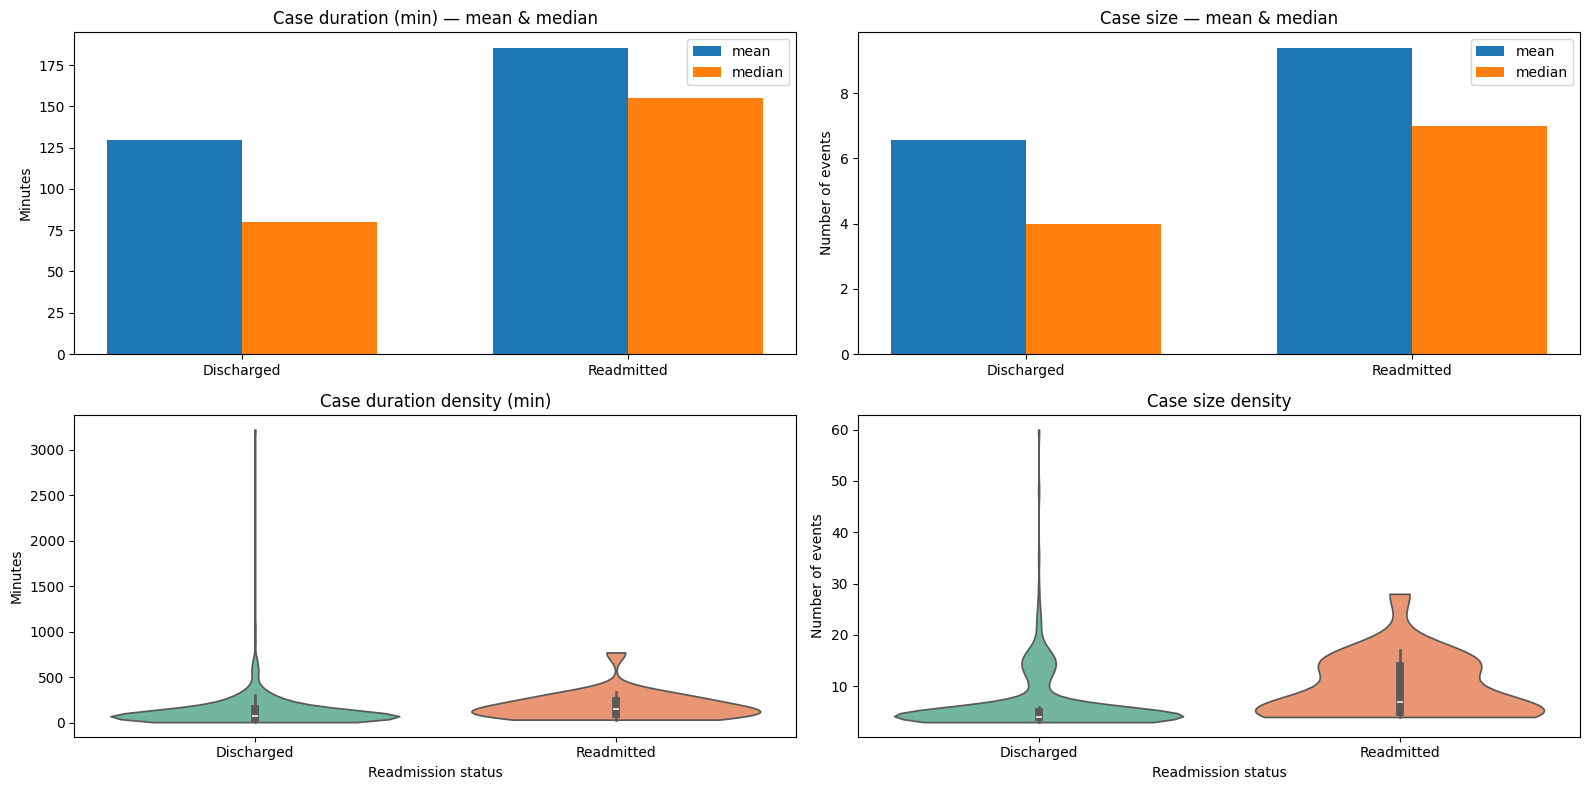

In [196]:
# Plot mean and median for duration and case size per segment
dur_mean = [kpi_discharged["duration_min"].mean(), kpi_readmitted["duration_min"].mean()]
dur_med = [kpi_discharged["duration_min"].median(), kpi_readmitted["duration_min"].median()]

size_mean = [kpi_discharged["case_size"].mean(), kpi_readmitted["case_size"].mean()]
size_med = [kpi_discharged["case_size"].median(), kpi_readmitted["case_size"].median()]

kpi_discharged_plot = kpi_discharged.copy()
kpi_discharged_plot['Readmission status'] = 'Discharged'

kpi_readmitted_plot = kpi_readmitted.copy()
kpi_readmitted_plot['Readmission status'] = 'Readmitted'

combined_kpis = pd.concat([kpi_discharged_plot, kpi_readmitted_plot])

labels = ["Discharged", "Readmitted"]
x = [0, 1]
width = 0.35

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))

# Duration plot
ax1.bar([xi - width / 2 for xi in x], dur_mean, width, label="mean")
ax1.bar([xi + width / 2 for xi in x], dur_med, width, label="median")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Case duration (min) — mean & median")
ax1.set_ylabel("Minutes")
ax1.legend()

# Case size plot
ax2.bar([xi - width / 2 for xi in x], size_mean, width, label="mean")
ax2.bar([xi + width / 2 for xi in x], size_med, width, label="median")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title("Case size — mean & median")
ax2.set_ylabel("Number of events")
ax2.legend()

# Duration plot
sns.violinplot(data=combined_kpis, x='Readmission status', y='duration_min', ax=ax3, palette='Set2', cut=0)
ax3.set_title("Case duration density (min)")
ax3.set_ylabel("Minutes")

# Case size plot
sns.violinplot(data=combined_kpis, x='Readmission status', y='case_size', ax=ax4, palette='Set2', cut=0)
ax4.set_title("Case size density")
ax4.set_ylabel("Number of events")

plt.tight_layout()
plt.show()

In [197]:
# Test KPIs between segments by Retorno (discharge)
print("\n=== Statistical analysis between discharged and readmitted cases ===\n")
kpis_to_test = ["duration_min", "case_size"]
compute_case_kpis_tests(kpi_discharged, kpi_readmitted, kpis_to_test)


=== Statistical analysis between discharged and readmitted cases ===

--- KPI: duration_min (Sample sizes: a=411, b=25) ---
Normality of segment a (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment b (Shapiro p-value): 0.0001 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0021
✅ There is a statistically significant difference between the two segments for 'duration_min'.

--- KPI: case_size (Sample sizes: a=411, b=25) ---
Normality of segment a (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment b (Shapiro p-value): 0.0004 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0000
✅ There is a statistically significant difference between the two segments for 'case_size'.



Conclusion: There are a significant difference for case duration and case size between `discharge` and `no discharge` segment.

### Outlier segmentation analysis

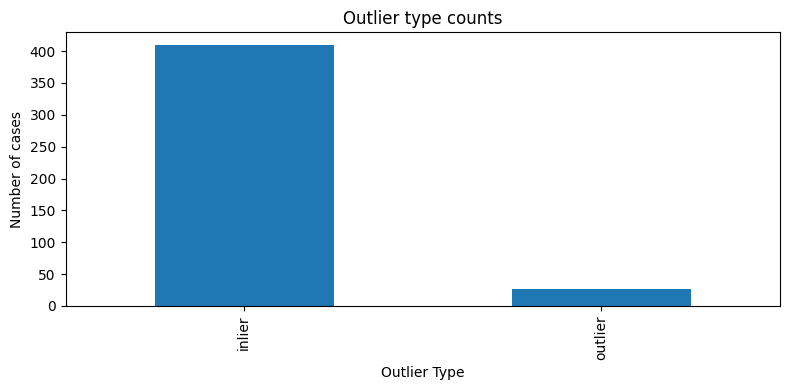

In [198]:
# Outlier frequency
outlier_counts = df.groupby("case:concept:name")["outlier_label"].first().value_counts()

ax = outlier_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Outlier type counts")
ax.set_xlabel("Outlier Type")
ax.set_ylabel("Number of cases")

plt.tight_layout()
plt.show()

In [199]:
# Segment by outlier type
outliers = df[df["outlier_label"] == "outlier"]
inlier = df[df["outlier_label"] != "outlier"]

In [200]:
# Compute KPIs for each segment
kpi_outlier = compute_case_kpis(outliers)
print(f"Outliers")
display(kpi_outlier.describe())

kpi_inlier = compute_case_kpis(inlier)
print(f"\nInliers")
display(kpi_inlier.describe())

Outliers


,duration_min,case_size
count,27.000000,27.000000
mean,619.037037,14.814815
std,552.073747,13.964342
min,334.000000,4.000000
25%,364.000000,5.000000
50%,465.000000,12.000000
75%,646.500000,16.500000
max,3221.000000,60.000000



Inliers


,duration_min,case_size
count,409.000000,409.000000
mean,100.506112,6.193154
std,73.370538,4.362760
min,8.000000,3.000000
25%,44.000000,4.000000
50%,78.000000,4.000000
75%,136.000000,5.000000
max,324.000000,29.000000


C:\Users\milan\AppData\Local\Temp\ipykernel_15776\1683579592.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='outlier_label', y='duration_min', ax=ax3, palette='Set2', cut=0)
C:\Users\milan\AppData\Local\Temp\ipykernel_15776\1683579592.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='outlier_label', y='case_size', ax=ax4, palette='Set2', cut=0)


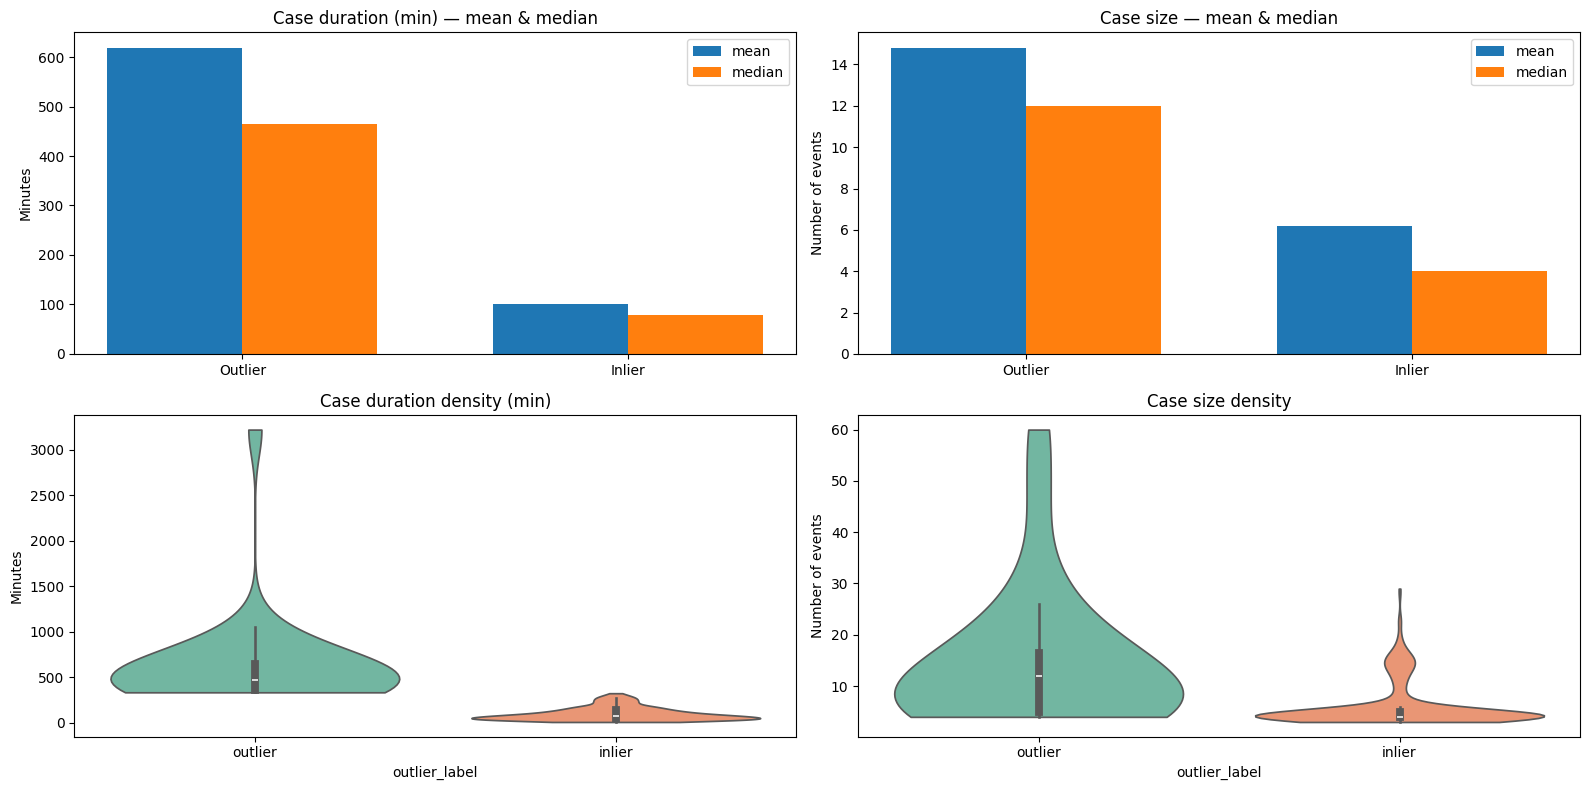

In [201]:
# Plot mean and median for duration and case size per segment
dur_mean = [kpi_outlier["duration_min"].mean(), kpi_inlier["duration_min"].mean()]
dur_med = [kpi_outlier["duration_min"].median(), kpi_inlier["duration_min"].median()]

size_mean = [kpi_outlier["case_size"].mean(), kpi_inlier["case_size"].mean()]
size_med = [kpi_outlier["case_size"].median(), kpi_inlier["case_size"].median()]

kpi_no_return_plot = kpi_outlier.copy()
kpi_no_return_plot['outlier_label'] = 'outlier'

kpi_with_return_plot = kpi_inlier.copy()
kpi_with_return_plot['outlier_label'] = 'inlier'

combined_kpis = pd.concat([kpi_no_return_plot, kpi_with_return_plot])

labels = ["Outlier", "Inlier"]
x = [0, 1]
width = 0.35

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))

# Duration plot
ax1.bar([xi - width / 2 for xi in x], dur_mean, width, label="mean")
ax1.bar([xi + width / 2 for xi in x], dur_med, width, label="median")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Case duration (min) — mean & median")
ax1.set_ylabel("Minutes")
ax1.legend()

# Case size plot
ax2.bar([xi - width / 2 for xi in x], size_mean, width, label="mean")
ax2.bar([xi + width / 2 for xi in x], size_med, width, label="median")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title("Case size — mean & median")
ax2.set_ylabel("Number of events")
ax2.legend()

# Duration plot
sns.violinplot(data=combined_kpis, x='outlier_label', y='duration_min', ax=ax3, palette='Set2', cut=0)
ax3.set_title("Case duration density (min)")
ax3.set_ylabel("Minutes")

# Case size plot
sns.violinplot(data=combined_kpis, x='outlier_label', y='case_size', ax=ax4, palette='Set2', cut=0)
ax4.set_title("Case size density")
ax4.set_ylabel("Number of events")

plt.tight_layout()
plt.show()

In [202]:
# Test KPIs between segments by Retorno (discharge)
print("=== Statistical analysis between outlier and inlier cases ===\n")
kpis_to_test = ["duration_min", "case_size"]
compute_case_kpis_tests(kpi_outlier, kpi_inlier, kpis_to_test)

=== Statistical analysis between outlier and inlier cases ===

--- KPI: duration_min (Sample sizes: a=27, b=409) ---
Normality of segment a (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment b (Shapiro p-value): 0.0000 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0000
✅ There is a statistically significant difference between the two segments for 'duration_min'.

--- KPI: case_size (Sample sizes: a=27, b=409) ---
Normality of segment a (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment b (Shapiro p-value): 0.0000 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0000
✅ There is a statistically significant difference between the two segments for 'case_size'.



Conclusion: There are a significant difference for case duration and case size between `outlier` and `inlier` segment.

### Case size and case time correlation

In [203]:
# Compute overall KPIs for the entire dataset
kpis_all = compute_case_kpis(df)
display(kpis_all.describe())

,duration_min,case_size
count,436.000000,436.000000
mean,132.616972,6.727064
std,197.285166,5.816844
min,8.000000,3.000000
25%,46.750000,4.000000
50%,82.000000,4.000000
75%,159.250000,5.250000
max,3221.000000,60.000000


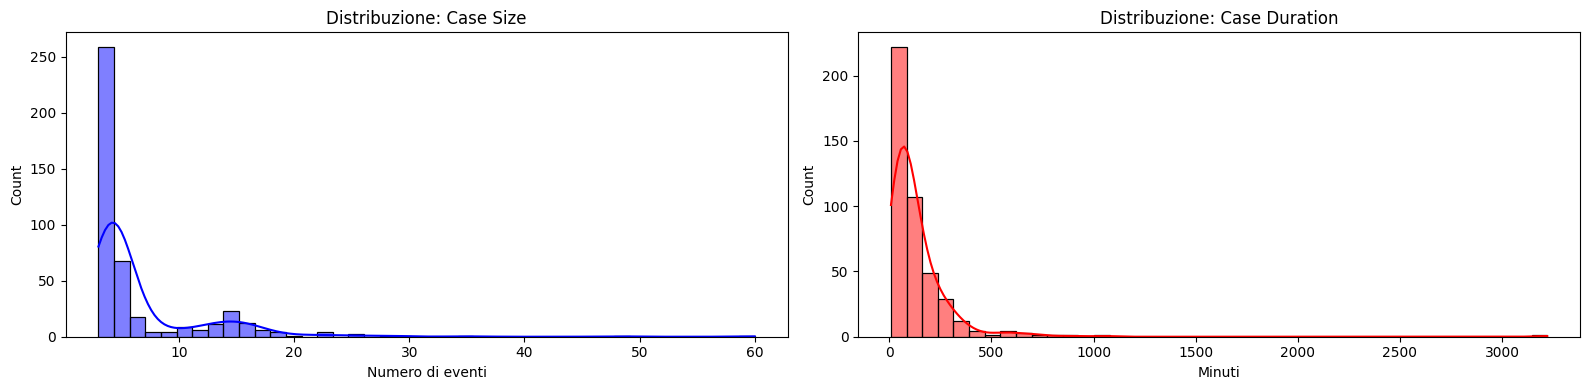

In [204]:
# Plot of case size and duration distributions 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.histplot(kpis_all["case_size"], kde=True, ax=axes[0], color='blue')
axes[0].set_title("Distribuzione: Case Size")
axes[0].set_xlabel("Numero di eventi")

sns.histplot(kpis_all["duration_min"], kde=True, ax=axes[1], color='red')
axes[1].set_title("Distribuzione: Case Duration")
axes[1].set_xlabel("Minuti")

plt.tight_layout()
plt.show()

In [205]:
# Test normality of case size and duration with Shapiro-Wilk test
_, p_size = stats.shapiro(kpis_all["case_size"])
_, p_duration = stats.shapiro(kpis_all["duration_min"])

print(f"Case Size - Shapiro p-value: {p_size:.4e} -> {'Normal' if p_size > 0.05 else 'Non-normal'}")
print(f"Case Duration - Shapiro p-value: {p_duration:.4e} -> {'Normal' if p_duration > 0.05 else 'Non-normal'}")

Case Size - Shapiro p-value: 2.2947e-32 -> Non-normal
Case Duration - Shapiro p-value: 7.9718e-35 -> Non-normal


In [206]:
# Since both distributions are non-normal, use Spearman's correlation to test the correlation between case size and duration
corr, p_val = stats.spearmanr(kpis_all["case_size"], kpis_all["duration_min"])

print(f"=== Correlation between case size and duration (Spearman) ===")
print(f"Spearman correlation coefficient: {corr:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ There is a statistically significant correlation between case size and case duration.")
else:
    print("\n❌ There is NOT statistically significant correlation between case size and case duration.")

=== Correlation between case size and duration (Spearman) ===
Spearman correlation coefficient: 0.5901
P-value: 2.9046e-42

✅ There is a statistically significant correlation between case size and case duration.


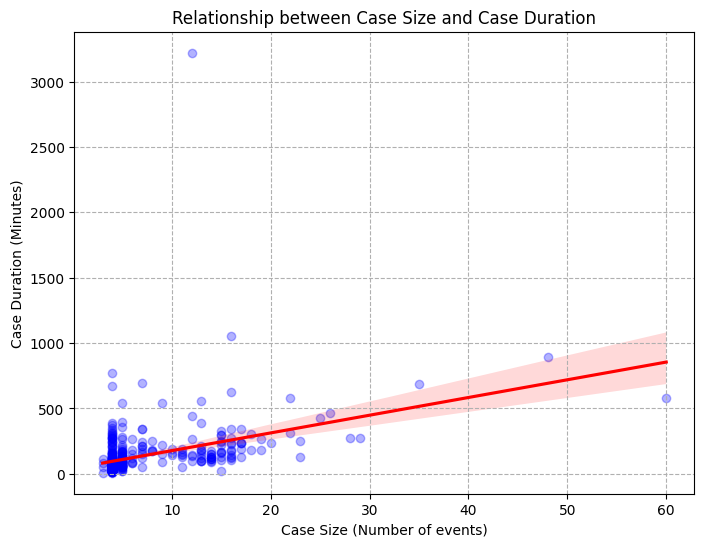

In [207]:
# Scatter plot with linear regression line to visualize the relationship between case size and duration
plt.figure(figsize=(8, 6))

sns.regplot(
    x=kpis_all["case_size"], 
    y=kpis_all["duration_min"], 
    scatter_kws={'alpha': 0.3, 'color': 'blue'}, 
    line_kws={'color': 'red'}
)
plt.title("Relationship between Case Size and Case Duration")
plt.xlabel("Case Size (Number of events)")
plt.ylabel("Case Duration (Minutes)")
plt.grid(linestyle='--')
plt.show()

Conclusion: there is a significant correlation between case size and case duration. We have a correlation coefficient of 0.5901 (> 0), so when case size increase, also case duration increase too.

### Readmissions and disease correlation

In [208]:
# Aggregate at case level to get one row per case with discharge_status and disease
corr_df = df.groupby("case:concept:name").agg(
    disease=("disease", "first"),
    readmission_status=("readmission_status", "first")
).reset_index()

corr_df["readmitted"] = (corr_df["readmission_status"] != "Sem retorno").astype(int)

corr_df.head()

,case:concept:name,disease,readmission_status,readmitted
0,5446538,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
1,5446540,R07.3 Outr dor toracica,Sem retorno,0
2,5446761,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
3,5446799,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
4,5446806,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0


In [209]:
# Crosstab for diseasea and readmission_status 
ct = pd.crosstab(corr_df["disease"], corr_df["readmission_status"])

ct 

readmission_status,Retorno em menos 24h,Retorno entre 24h e 48h,Retorno entre 48h e 72h,Sem retorno
disease,,,,
I64 Acid vasc cerebr NE como hemorrag isquemico,0,0,0,1
J10.1 Influenz c/out manif resp dev vir infl ident,0,0,0,1
J11.1 Influenza c/out manif resp dev virus n ident,4,6,4,335
J12.9 Pneumonia viral NE,0,0,0,3
N23 Colica nefretica NE,6,2,1,38
R07.3 Outr dor toracica,0,0,0,5
R07.4 Dor toracica NE,1,0,1,28


In [210]:
# Normalize to get proportions per disease
ct_norm = pd.crosstab(
    corr_df["disease"],
    corr_df["readmission_status"],
    normalize="index"
)

ct_norm

readmission_status,Retorno em menos 24h,Retorno entre 24h e 48h,Retorno entre 48h e 72h,Sem retorno
disease,,,,
I64 Acid vasc cerebr NE como hemorrag isquemico,0.000000,0.000000,0.000000,1.000000
J10.1 Influenz c/out manif resp dev vir infl ident,0.000000,0.000000,0.000000,1.000000
J11.1 Influenza c/out manif resp dev virus n ident,0.011461,0.017192,0.011461,0.959885
J12.9 Pneumonia viral NE,0.000000,0.000000,0.000000,1.000000
N23 Colica nefretica NE,0.127660,0.042553,0.021277,0.808511
R07.3 Outr dor toracica,0.000000,0.000000,0.000000,1.000000
R07.4 Dor toracica NE,0.033333,0.000000,0.033333,0.933333


C:\Users\milan\AppData\Local\Temp\ipykernel_15776\3307879246.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1600x800 with 0 Axes>

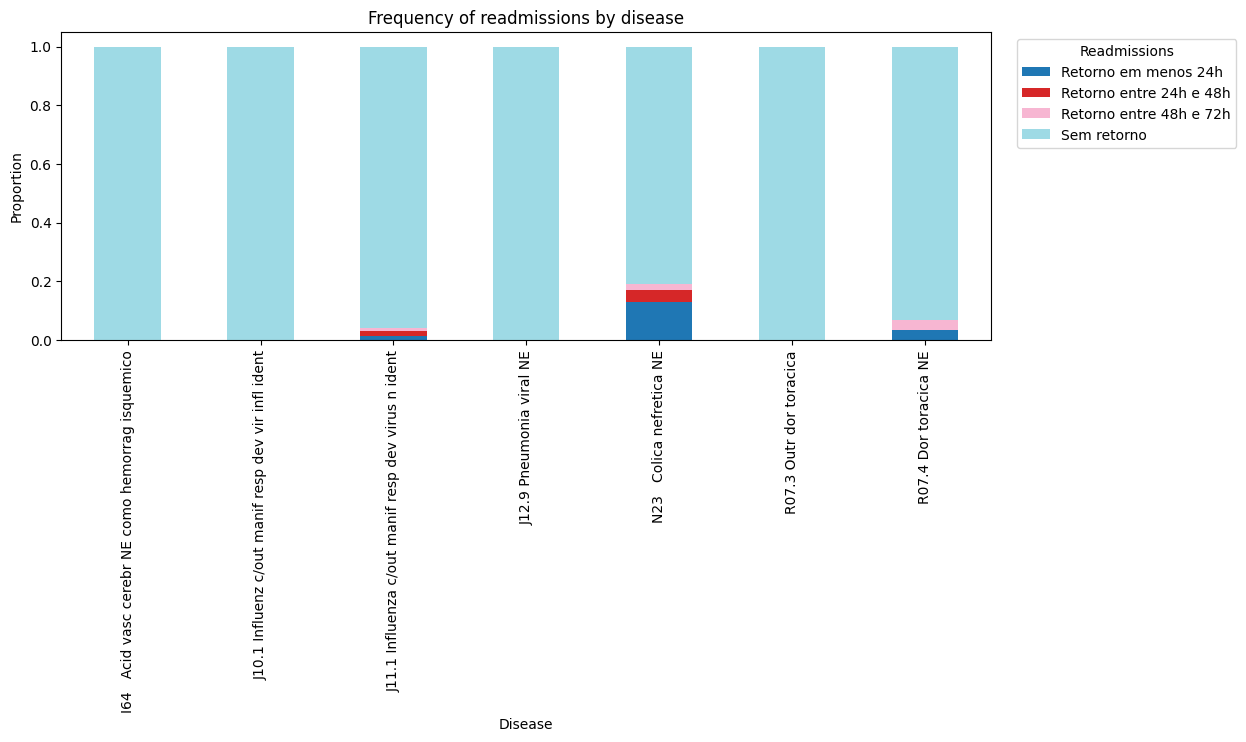

C:\Users\milan\AppData\Local\Temp\ipykernel_15776\3307879246.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=readmit_rate.values, y=readmit_rate.index, palette="magma")


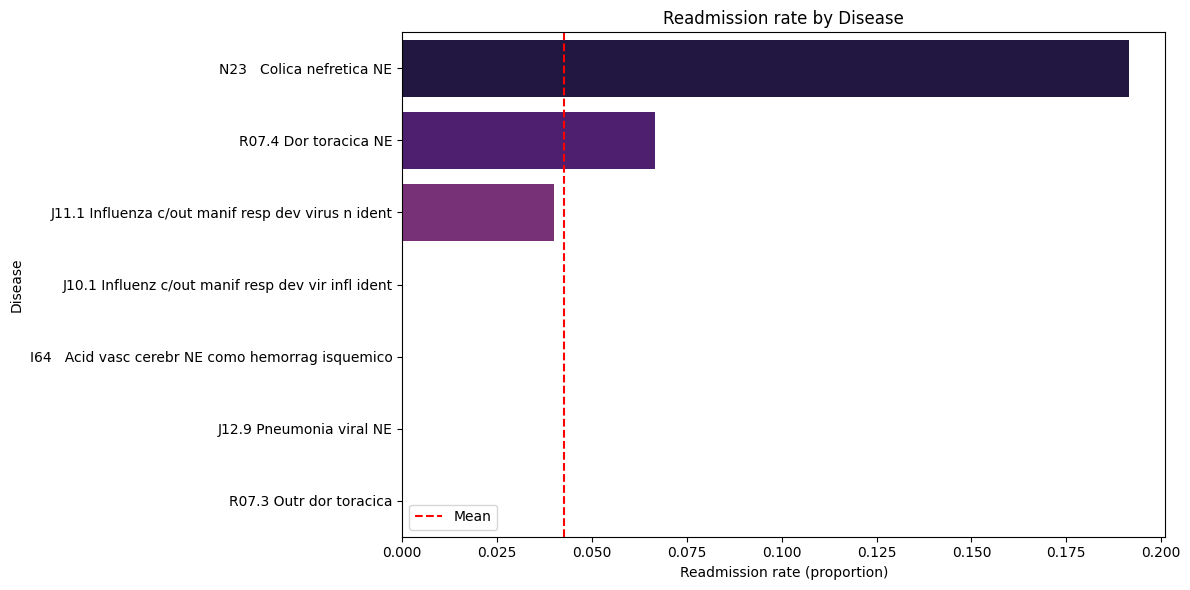

In [211]:
# Plot stacked bar: frequency of Retorno by disease
plt.figure(figsize=(16, 8))
ct_norm.plot(kind="bar", stacked=True, colormap="tab20", figsize=(12, 4))
plt.title("Frequency of readmissions by disease")
plt.ylabel("Proportion")
plt.xlabel("Disease")
plt.legend(title="Readmissions", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot readmission rate per disease
readmit_rate = corr_df.groupby("disease")["readmitted"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=readmit_rate.values, y=readmit_rate.index, palette="magma")
plt.axvline(readmit_rate.mean(), linestyle="--", color="red", label="Mean")
plt.xlabel("Readmission rate (proportion)")
plt.ylabel("Disease")
plt.title("Readmission rate by Disease")
plt.tight_layout()
plt.legend()
plt.show()

In [212]:
# Chi-squared test of independence between disease and readmission status on the complete contingency table
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-squared test: chi2={chi2:.2f}, p-value={p:.4f}, dof={dof}")

# Chi-squared test is valid if expected frequencies are all > 5
if (expected <= 5).sum() == 0:
    if p < 0.05:
        print("✅ There is a statistically significant association between disease and discharge status (readmission).")
    else:    
        print("❌ There is NOT a statistically significant association between disease and discharge status (readmission).")
else:
    print("⚠️ Some expected frequencies are not greater than 5, chi-squared test may not be valid.")

Chi-squared test: chi2=27.10, p-value=0.0771, dof=18
⚠️ Some expected frequencies are not greater than 5, chi-squared test may not be valid.


In [213]:
# For each disease, test of independence regarding readmission status vs all other diseases combined
# Fisher's exact test to calculates the exact probability of observing the data given the null hypothesis 
# of independence, without relying on large-sample approximations like previous Chi-squared test. 
# Since we are analyzing readmission rates for specific diseases, some diseases may have low 
# counts, making Fisher's exact test a better choice to assess the association between disease 
# and readmission status.
res = []
for disease, group in corr_df.groupby("disease"):
    others = corr_df[corr_df["disease"] != disease]

    a = group["readmitted"].sum()   # disease & readmitted
    b = len(group) - a              # disease & not readmitted
    c = others["readmitted"].sum()  # others & readmitted
    d = len(others) - c             # others & not readmitted

    # Avoid division by zero and invalid contingency tables for fisher-exact test
    try:
        odds_ratio, p_fisher = stats.fisher_exact([[a, b], [c, d]])
    except:
        odds_ratio, p_fisher = np.nan, np.nan

    res.append({
        "disease": disease,
        "count": len(group),
        "readmit_rate": a / (a + b) if (a + b) else np.nan,
        "odds_ratio": odds_ratio,
        "p_fisher": p_fisher
    })

res = pd.DataFrame(res).sort_values("p_fisher").reset_index(drop=True)

# Adjust p-values for multiple testing using Bonferroni correction to reduce the chances of 
# false positives when performing multiple comparisons.
res["p_adj"] = multipletests(res["p_fisher"], method="bonferroni")[1]

display(res)

# Significant associations of diseases and readmission where p-value < 0.05
sig = res[res["p_adj"] < 0.05]

if len(sig) > 0:
    print(f"There are {len(sig)} diseases with significant association (Fisher p < 0.05):")
    for disease in sig["disease"]: print(disease)
else:
    print("No significant association found between diseases and readmission type.")

,disease,count,readmit_rate,odds_ratio,p_fisher,p_adj
0,N23 Colica nefretica NE,47,0.191489,5.521382,0.000501,0.003506
1,J11.1 Influenza c/out manif resp dev virus n i...,349,0.040115,0.288738,0.004221,0.029547
2,R07.4 Dor toracica NE,30,0.066667,1.189441,0.686665,1.000000
3,I64 Acid vasc cerebr NE como hemorrag isquemico,1,0.000000,0.000000,1.000000,1.000000
4,J12.9 Pneumonia viral NE,3,0.000000,0.000000,1.000000,1.000000
5,J10.1 Influenz c/out manif resp dev vir infl i...,1,0.000000,0.000000,1.000000,1.000000
6,R07.3 Outr dor toracica,5,0.000000,0.000000,1.000000,1.000000


There are 2 diseases with significant association (Fisher p < 0.05):
N23   Colica nefretica NE
J11.1 Influenza c/out manif resp dev virus n ident


Conclusion: we have found a significant correlation between `N23   Colica nefretica NE` and `J11.1 Influenza c/out manif resp dev virus n ident` diseases and readmission compared to the others diseases:
- `N23   Colica nefretica NE`: has an odds ratio of 5.521382 (> 1), who has this disease returns 5.5 times more than normal
- `J11.1 Influenza c/out manif resp dev virus n ident`: has an odds ratio of 0.288738 (< 1), who has this disease returns 0.288738 times less than normal

### Triage Analysis

In [ ]:
df["process_time_min"] = (df["time:timestamp"] - df["start_date"]).dt.total_seconds() / 60

triage = df[
    (df["concept:name"] == "Triagem") &
    (df["process_time_min"] < 1440)  # Filter out cases with process time >= 24 hours (outliers)
].copy()

print(triage["process_time_min"].describe())

# Normality test
stat_sw, p_sw = stats.shapiro(triage["process_time_min"])
print(f"\nShapiro-Wilk p={p_sw:.4f}")

if p_sw > 0.05:
    print("Data is normally distributed → use parametric confidence interval")
else:    
    print("Data is NOT normally distributed → use bootstrap confidence interval")

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(triage["process_time_min"], kde=True, bins=20, color='skyblue')
plt.title("Triage Service Time (minutes)")
plt.xlabel("Service time (min)")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.boxplot(x=triage["process_time_min"], color='lightgreen')
plt.title("Triage Service Time - Boxplot")
plt.xlabel("Service time (min)")

plt.tight_layout()
plt.show()